# The Cramér-Lundberg modelling of risk in non-life insurance




The Cramér-Lundberg model is a foundational mathematical framework used primarily in actuarial science and quantitative risk management. 
It is specifically designed to model the "surplus" or "wealth" process of an insurance company over time.The model is useful in several key areas of the insurance industry. It helps insurers determine the probability of ruin: "the scenario where claims exceed the company's available capital ($R_t < 0$)".



## Model Overview
In this section, we analyze the wealth of an insurance company modeled as a jump process. The wealth at time $t$, denoted by $R_t$, is defined by the following equation:

$$R_{t}=u+pt-\sum_{i=1}^{N_{t}}Y_{i}$$

### Model Parameters:
**$u \ge 0$**: The initial capital of the company.

**$p > 0$**: The premium rate collected per unit of time.

**$N = (N_t)_{t \ge 0}$**: A homogeneous Poisson process with intensity $\mu > 0$ representing the number of claims.

**$(Y_i)_{i \ge 1}$**: A sequence of independent and identically distributed (iid) positive random variables representing the amount of each claim.

**$m = \mathbb{E}[Y_1]$**: The expected value of a claim, assumed to be finite.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def simulation_richesse(mu,T,beta,u,n,theta):
    p=(1+theta)*mu*1/beta
    Nt=np.random.poisson(mu*T,1)[0]
    temps_arrivee=np.random.uniform(0,T,Nt)
    temps_arrivee=np.sort(temps_arrivee)
    Y=np.random.exponential(1/beta,Nt)
    t=np.arange(0,T,1/n)
    Rt = np.zeros(len(t))
    
    for idx, ti in enumerate(t):
        mask = temps_arrivee <= ti  # sinistres survenus avant ti
        if mask.sum() > 0:
            somme = np.sum(Y[mask])
        else:
            somme = 0
        Rt[idx] = u + p * ti - somme
    return (t,Rt)

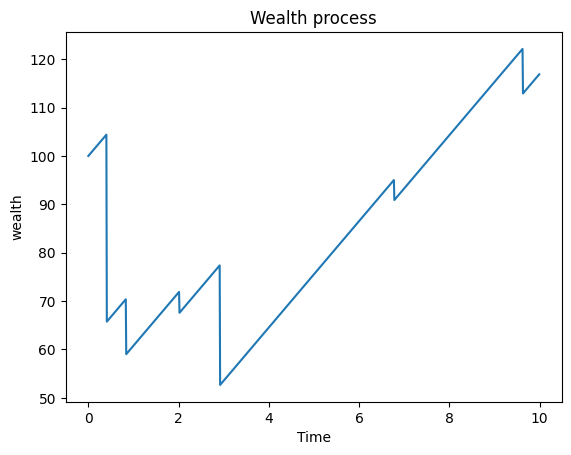

In [5]:
mu=1
T=10
beta=0.1
theta=0.1
n=100
u=100
t,Rt=simulation_richesse(mu,T,beta,u,n,theta)
plt.plot(t,Rt)
plt.title("Wealth process")
plt.xlabel("Time")
plt.ylabel("wealth")
plt.show()

## Study Objectives
The risk analysis focuses on two main axes:

### 1. Profitability Condition
We aim to determine the critical premium rate value, denoted as $p^*$, such that for any $p > p^*$, the expected wealth $\mathbb{E}[R_t]$ remains strictly positive for all $t$. This ensures the company is structurally profitable.



1) To determine the expected wealth at time $t$, we use the linearity of expectation and the properties of the compound Poisson process
$\mathbb{E}[R_{t}] = \mathbb{E}[u + pt] - \mathbb{E}\left[\sum_{i=1}^{N_{t}} Y_{i}\right]$. Since $u$ and $p$ are constant parameters, $\mathbb{E}[u + pt] = u + pt$. Compound Poisson Process: According to Wald's identity, the expectation of a random sum where $N_t$ follows a Poisson process with parameter $\mu t$ and the $(Y_i)$ are iid with mean $m$ is given by:
$$\mathbb{E}\left[\sum_{i=1}^{N_{t}} Y_{i}\right] = \mathbb{E}[N_t] \cdot \mathbb{E}[Y_1] = \mu t \cdot m$$ Result: The explicit form of the expected wealth at any time $t$ is:$$\mathbb{E}[R_{t}] = u + (p - \mu m)t$$
2) We are looking for the value $p^*$ such that for any $p > p^*$, the expected wealth remains strictly positive for any time $t \ge 0$. Based on the formula established previously:$$\mathbb{E}[R_{t}] = u + t(p - \mu m)$$For this value to remain strictly positive regardless of $t$ (particularly as $t \to +\infty$), the slope of the line must be strictly positive or zero, provided that the initial capital $u$ ensures positivity at $t=0$. Since $u \ge 0$, the condition $\mathbb{E}[R_{t}] > 0$ for any $t$ requires the drift of the process to be positive: $p - \mu m > 0$. From this, we derive the critical value $p^*$:$$p^* = \mu m$$

### 2. Ruin Probability (Approximation)
The regulator is interested in the probability that the company goes bankrupt during the contract period. We study a simplified version of ruin at horizon $T$, defined by the Bernoulli random variable $\mathcal{R}$:
$$\{\mathcal{R}=1\} \Leftrightarrow \{R_{T} < 0\}$$

The goal is to analyze the impact of the initial capital $u$ on this probability $\mathbb{P}[\mathcal{R}=1]$ using **Monte-Carlo** simulations.

## Simulation Parameters
For the numerical applications, the following values are fixed:
**Time Horizon**: $T = 100$ 
**Intensity**: $\mu = 1$ 
**Claim Distribution**: $Y_i \sim \mathcal{E}(\beta)$ with $\beta = 0.1$ 
***Premium Rate**: $p = (1+\theta)p^*$ with a safety loading $\theta = 30\%$ 

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
##"Estimation of Rt"
def estimation_ruine(mu,T,beta,u,theta,n) :
    nb_ruine=0
    p=(1+theta)*mu*1/beta
    for i in range (n) :
        
        Nt=np.random.poisson(mu*T,1)[0]
        temps_arrivee=np.random.uniform(0,T,Nt)
        temps_arrivee=np.sort(temps_arrivee)
        #print(Nt)
        #print(temps_arrivee)
        Y=np.random.exponential(1/beta,Nt)
        #print(Y)
        sinistres=np.cumsum(Y)
        #print(sinistres)
        for j in range(Nt):
            if u+p*temps_arrivee[j]-sinistres[j]<=0 :
                nb_ruine+=1
                break
    return nb_ruine/n

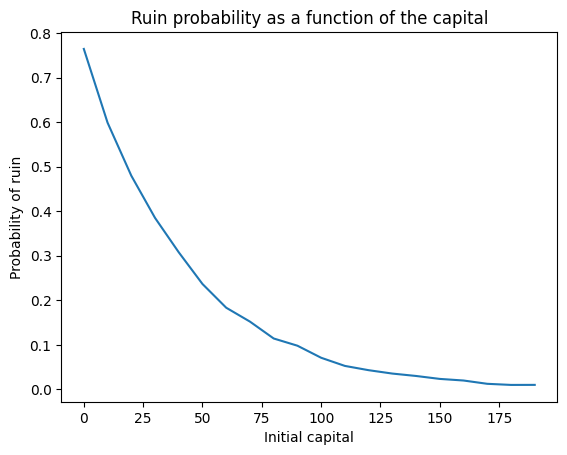

In [8]:
##"Ruin probability as a function of the capital"
mu=1
T=100
beta=0.1
theta=0.3
n=10000
proba_ruine=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine[k]=estimation_ruine(mu,T,beta,u[k],theta,n)

plt.plot(u,proba_ruine)
plt.title("Ruin probability as a function of the capital")
plt.xlabel("Initial capital")
plt.ylabel("Probability of ruin")
plt.show()

-0.0285062159787431


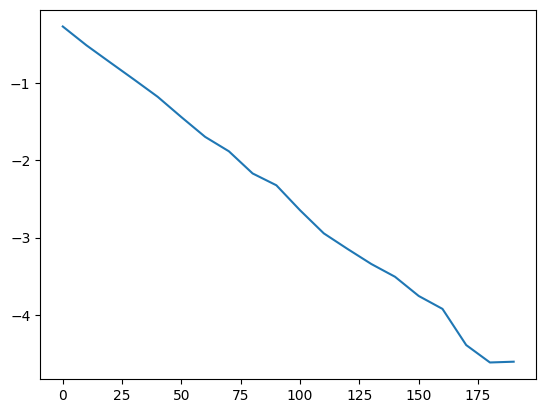

In [9]:
##"Estimation of k"
log_proba_ruine=np.log(proba_ruine)
plt.plot(u,log_proba_ruine)
kappa=np.mean(log_proba_ruine[1:20]/u[1:20])
print(kappa)

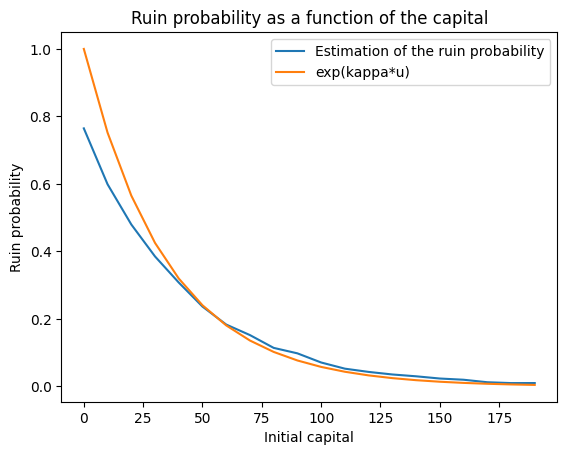

In [10]:
##"Comaparaison Estimation and exponential model "
plt.plot(u,proba_ruine,label="Estimation of the ruin probability")
plt.plot(u,np.exp(kappa*u),label="exp(kappa*u)")
plt.title("Ruin probability as a function of the capital")
plt.xlabel("Initial capital")
plt.ylabel("Ruin probability")
plt.legend()
plt.show()

---

## 2.2 Opening - The Discounted Cramér-Lundberg Model

The classical Cramér-Lundberg model treats all claims symmetrically: a sinister of amount $Y_i$ that arrived long ago impacts the current reserve at time $t$ with its full nominal weight, exactly as if it had just occurred. In practice, however, actuaries and financial regulators routinely reason in terms of **discounted cash flows** , a liability incurred in the distant past has been provisioned for, and its present-day financial burden is smaller than its face value.

This motivates the following extension of model (1), in which each claim is weighted by a discount factor that decays exponentially with the time elapsed since it arrived:

$$R_t = u + pt - \sum_{i=1}^{N_t} e^{-\rho(t - \tau_i)} Y_i, \quad t \geq 0 \tag{2}$$

where $\tau_i = \inf\{t > 0,\ N_t = i\}$ is the arrival time of the $i$-th claim and $\rho \geq 0$ is the **discount rate**. The factor $e^{-\rho(t-\tau_i)} \in (0,1]$ diminishes the effective impact of claim $i$ on the current reserve: the older the claim, the smaller its discounted weight. When $\rho = 0$, every discount factor equals 1 and one recovers model (1) exactly , making (2) a genuine generalization of the classical framework.

We analyze this new model along the same two axes as before: first the expected wealth and its safety loading condition, then the ruin probability via Monte-Carlo simulation.

### Expected Wealth of the Company

We begin by computing $\mathbb{E}[R_t]$, where $N$ is a homogeneous Poisson process with intensity $\mu$, the $Y_i$ are i.i.d. positive random variables and $m = \mathbb{E}[Y_1]$.

**Taking the expectation of $R_t$.**
By linearity of expectation,
$$\mathbb{E}[R_t] = u + pt - \mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}Y_i\right].$$
The deterministic terms are straightforward; the whole difficulty lies in computing the last term.

**Separating the claims from the arrival times.**
Since the $Y_i$ are independent of the Poisson process and all share the same mean $m$, we can factor the expectation:
$$\mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}Y_i\right] = m\,\mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}\right].$$
This is the same idea as in the classical model , replace each random claim by its mean , except that here each claim is additionally weighted by its discount factor.

**Conditioning on the number of claims.**
Since $N_t$ is itself random, we condition on $N_t = n$:
$$\mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}\right] = \sum_{n=0}^{\infty} \mathbb{E}\left[\sum_{i=1}^{n} e^{-\rho(t-\tau_i)} \,\middle|\, N_t=n\right]\mathbb{P}(N_t=n).$$
A classical result on Poisson processes states that, given $N_t = n$, the arrival times $\tau_1, \dots, \tau_n$ are distributed as the order statistics of $n$ i.i.d. uniform random variables on $[0, t]$. In other words, knowing that exactly $n$ claims occurred before $t$, their arrival times are spread uniformly over $[0, t]$.

**Computing the conditional expectation.**
Using this uniform distribution, and denoting $U \sim \mathcal{U}([0,t])$,
$$\mathbb{E}\left[\sum_{i=1}^{n} e^{-\rho(t-\tau_i)} \,\middle|\, N_t=n\right] = n\,\mathbb{E}\left[e^{-\rho(t-U)}\right] = \frac{n}{t}\int_0^t e^{-\rho(t-s)}\,ds.$$

**Removing the conditioning.**
Plugging back into the sum and factoring out the integral,
$$\mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}\right] = \left(\frac{1}{t}\int_0^t e^{-\rho(t-s)}\,ds\right) \sum_{n=0}^{\infty} n\,\mathbb{P}(N_t=n) = \left(\frac{1}{t}\int_0^t e^{-\rho(t-s)}\,ds\right)\mathbb{E}[N_t].$$
Since $N_t \sim \mathcal{P}(\mu t)$, we have $\mathbb{E}[N_t] = \mu t$, and therefore
$$\mathbb{E}\left[\sum_{i=1}^{N_t} e^{-\rho(t-\tau_i)}\right] = \mu \int_0^t e^{-\rho(t-s)}\,ds.$$

**Closed-form result.**
Collecting everything and computing the integral via the substitution $v = t - s$,
$$\mathbb{E}[R_t] = u + pt - \mu m \int_0^t e^{-\rho(t-s)}\,ds = \boxed{u + pt - \frac{\mu m}{\rho}\left(1 - e^{-\rho t}\right)} \quad (\rho > 0).$$
When $\rho = 0$, the discount factor is trivially 1 and one recovers the classical result $\mathbb{E}[R_t] = u + pt - \mu m t$, consistent with the fact that the discounted model is a generalization of the classical one.

### The Safety Loading Condition

We now determine the critical premium rate $p^*$ below which the company's expected wealth can become negative.

**Convexity of the expected wealth.**
We differentiate $t \mapsto \mathbb{E}[R_t]$:
$$\frac{d}{dt}\mathbb{E}[R_t] = p - \mu m\, e^{-\rho t}.$$
The second derivative is
$$\frac{d^2}{dt^2}\mathbb{E}[R_t] = \mu m \rho\, e^{-\rho t} > 0 \quad \text{for all } t \geq 0,$$
so $t \mapsto \mathbb{E}[R_t]$ is **strictly convex**, and any critical point is necessarily a global minimum.

**Case $p \geq \mu m$.**
The first derivative is non-negative for all $t \geq 0$, so $\mathbb{E}[R_t]$ is non-decreasing. Since $\mathbb{E}[R_0] = u \geq 0$, we conclude that $\mathbb{E}[R_t] \geq u \geq 0$ for all $t$.

**Case $p < \mu m$.**
The first derivative vanishes at
$$t^* = \frac{1}{\rho}\ln\!\left(\frac{\mu m}{p}\right) > 0,$$
which is, by convexity, the unique global minimum. Substituting $e^{-\rho t^*} = \frac{p}{\mu m}$, the minimum value is
$$\mathbb{E}[R_{t^*}] = u + \frac{p}{\rho}\ln\!\left(\frac{\mu m}{p}\right) - \frac{\mu m - p}{\rho}.$$
We now show that the second and third terms combine to a strictly negative quantity. Setting $x = \frac{\mu m}{p} > 1$, this reduces to proving that $\ln(x) < x - 1$ for all $x > 1$. Define $g(x) = x - 1 - \ln(x)$. Then $g(1) = 0$ and $g'(x) = 1 - \frac{1}{x} > 0$ for $x > 1$, so $g$ is strictly increasing on $[1, +\infty)$, giving $g(x) > 0$, i.e., $\ln(x) < x - 1$. Therefore $\mathbb{E}[R_{t^*}] < u$, and in particular $\mathbb{E}[R_{t^*}] < 0$ when $u = 0$.

**Conclusion.**
The condition $\mathbb{E}[R_t] > 0$ for all $t \geq 0$ is guaranteed if and only if $p > \mu m$, regardless of the initial capital $u$. The critical premium rate is therefore

$$\boxed{p^* = \mu m = \frac{\mu}{\beta}.}$$

This threshold is **identical** to that of the classical model, which can be confirmed by letting $\rho \to 0$: using $e^{-\rho t} \approx 1 - \rho t$, we get $\frac{\mu m}{\rho}(1 - e^{-\rho t}) \to \mu m t$, recovering $p^* = \mu m$.

**A key qualitative difference.**
Although the critical threshold is the same, the behaviour of the model below $p^*$ differs fundamentally from the classical case. In the classical model, $\mathbb{E}[R_t] \to -\infty$ when $p < p^*$. In the discounted model, the total discounted claims are bounded:
$$\frac{\mu m}{\rho}(1 - e^{-\rho t}) \xrightarrow[t \to \infty]{} \frac{\mu m}{\rho} < +\infty,$$
so $\mathbb{E}[R_t] \to +\infty$ regardless of $p$. The financial risk is therefore **concentrated in the short term**, making the discounted model structurally more favourable for the insurer over long time horizons.

### Numerical Simulations

With the theoretical framework in place, we now proceed to numerical experiments. The simulation approach closely mirrors the one developed for the classical model: we generate paths of $R_t$ by sampling Poisson arrival times and exponential claims, then apply the discount factor $e^{-\rho(t-\tau_i)}$ to each past claim according to how long ago it arrived.

The parameters are kept identical to Section 2.1 , $T = 100$, $\mu = 1$, $Y_i \sim \mathcal{E}(\beta)$ with $\beta = 0.1$, $p = (1+\theta)p^*$ with $\theta = 30\%$ , so that comparisons between the two models are meaningful. We additionally fix $m = \mathbb{E}[Y_1] = 1/\beta = 10$, so that $p^* = \mu m = 10$.

In [11]:
def simulation_discounted(mu,T,beta,u,n,theta,rho):
    p=(1+theta)*mu*1/beta
    Nt=np.random.poisson(mu*T,1)[0]
    temps_arrivee=np.random.uniform(0,T,Nt)
    temps_arrivee=np.sort(temps_arrivee)
    Y=np.random.exponential(1/beta,Nt)
    t=np.arange(0,T,1/n)
    exp=np.exp(rho*temps_arrivee)
    coefs_somme=np.array(Y)*np.array(exp)
    sinistres=np.cumsum(coefs_somme)
    #Rt=u+p*t-np.exp(-rho*t)*np.cumsum(np.exp(rho*np.array(temps_arrivee[temps_arrivee<=t]))*np.array(Y[temps_arrivee<=t]))
    Rt = np.zeros(len(t))
    
    for idx, ti in enumerate(t):
        mask = temps_arrivee <= ti  # sinistres survenus avant ti
        if mask.sum() > 0:
            somme = np.sum(np.exp(-rho * (ti - temps_arrivee[mask])) * Y[mask])
        else:
            somme = 0
        Rt[idx] = u + p * ti - somme
    return (t,Rt)

The function `simulation_discounted` adapts `simulation_richesse` to the discounted setting. The structural logic is identical , sample $N_t \sim \mathcal{P}(\mu T)$ arrivals, draw their times uniformly and sort them, draw exponential claim amounts , but the inner loop now computes the **discounted aggregate** at each time step $t_i$:

$$\sum_{j\,:\,\tau_j \leq t_i} e^{-\rho(t_i - \tau_j)}\, Y_j$$

rather than the raw cumulative sum $\sum_j Y_j$. This is implemented by applying `np.exp(-rho * (ti - temps_arrivee[mask]))` as a weight vector to the claim amounts before summing. Claims that occurred long ago are exponentially down-weighted, which is exactly the financial discounting mechanism introduced in model (2).

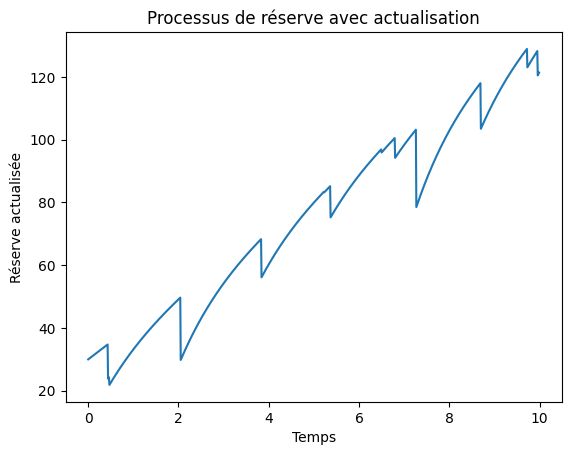

In [12]:
mu=1
T=10
beta=0.1
theta=0.1
n=100
rho=1
u=30
t,Rt=simulation_discounted(mu,T,beta,u,n,theta,rho)
plt.plot(t,Rt)
plt.title("Processus de réserve avec actualisation")
plt.xlabel("Temps")
plt.ylabel("Réserve actualisée")
plt.show()

Comparing this trajectory to the classical model is instructive. In model (1), each claim event causes an instantaneous downward jump of the full amount $Y_i$, which persists indefinitely. In model (2), a large sinister that occurred early gradually fades out of the reserve computation as $e^{-\rho(t-\tau_i)} \to 0$, giving the process a smoother long-run profile. For large $\rho$, past claims become negligible very quickly and the reserve essentially grows at rate $p$ in the long run , a manifestation of the structural advantage noted in the theoretical analysis.

### Ruin Probability in the Discounted Model

We now estimate the ruin probability $\mathbb{P}[R_T < 0]$ as a function of the initial capital $u$, using the same Monte-Carlo framework as in Section 2.1. The ruin check at each claim epoch $\tau_j$ is adapted to account for discounting: the effective liability at time $\tau_j$ is the discounted sum $e^{-\rho \tau_j} \sum_{k \leq j} e^{\rho \tau_k} Y_k$, which is computed incrementally using the cumulative sums of the weighted amounts $e^{\rho \tau_k} Y_k$.

In [13]:
def estimation_ruine_discounted(mu,T,beta,u,theta,n,rho) :
    nb_ruine=0
    p=(1+theta)*mu*1/beta
    for i in range (n) :
        
        Nt=np.random.poisson(mu*T,1)[0]
        temps_arrivee=np.random.uniform(0,T,Nt)
        temps_arrivee=np.sort(temps_arrivee)
        Y=np.random.exponential(1/beta,Nt)
        exp=np.exp(rho*temps_arrivee)
        coefs_somme=np.array(Y)*np.array(exp)
        sinistres=np.cumsum(coefs_somme)
        #print(sinistres)
        for j in range(Nt):
            if u+p*temps_arrivee[j]-np.exp(-rho*temps_arrivee[j])*sinistres[j]<=0 :
                nb_ruine+=1
                break
    return nb_ruine/n

We fix $\rho = 0.1$ and compute the ruin probability for $u \in \{0, 10, 20, \ldots, 190\}$ using $n = 1\,000$ Monte-Carlo replications per value of $u$. The remaining parameters are unchanged: $\mu = 1$, $\beta = 0.1$, $T = 100$, $\theta = 30\%$.

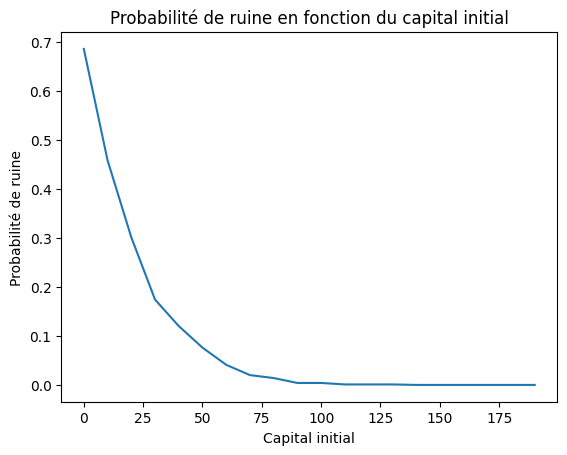

In [14]:
mu=1
T=100
beta=0.1
theta=0.3
n=1000
rho=0.1
proba_ruine_discounted=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine_discounted[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho)

plt.plot(u,proba_ruine_discounted)
plt.title("Probabilité de ruine en fonction du capital initial")
plt.xlabel("Capital initial")
plt.ylabel("Probabilité de ruine")
plt.show()

### Exponential Fit of the Ruin Probability

As in the classical model, we investigate whether the ruin probability decays exponentially with the initial capital $u$. Taking the logarithm of the estimated probabilities and fitting a linear function through the origin, we extract a characteristic decay rate $\kappa_\rho$ for the discounted model:

$$\mathbb{P}[R_T < 0] \approx e^{-\kappa_\rho\, u}.$$

The slope $\kappa_\rho$ is estimated by averaging the ratios $\log\hat{p}(u_k)/u_k$ over all non-zero capital values, mirroring the approach used in Section 2.1.

C:\Users\brule\AppData\Local\Temp\ipykernel_16320\3210614808.py:2: RuntimeWarning: divide by zero encountered in log
  log_proba_ruine_discounted = np.log(proba_ruine_discounted)


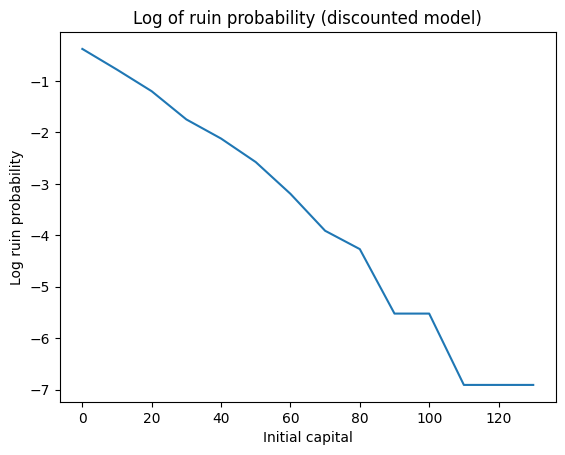

-inf


In [15]:
## Estimation of kappa for the discounted model
log_proba_ruine_discounted = np.log(proba_ruine_discounted)
plt.plot(u, log_proba_ruine_discounted)
plt.title("Log of ruin probability (discounted model)")
plt.xlabel("Initial capital")
plt.ylabel("Log ruin probability")
plt.show()

kappa_discounted = np.mean(log_proba_ruine_discounted[1:20] / u[1:20])
print(kappa_discounted)

C:\Users\brule\AppData\Local\Temp\ipykernel_16320\2656242758.py:3: RuntimeWarning: invalid value encountered in multiply
  plt.plot(u, np.exp(kappa_discounted * u), label="exp(kappa*u)")


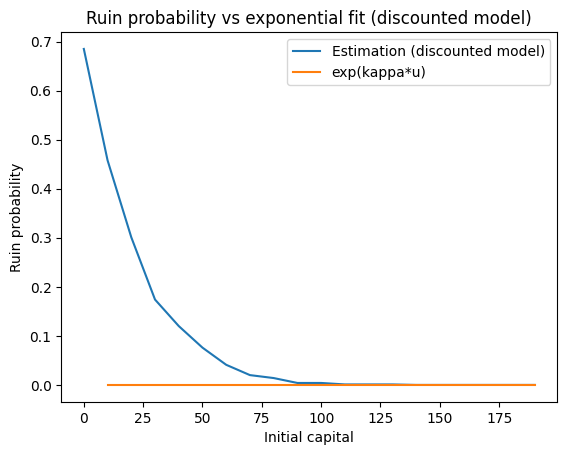

In [16]:
## Comparison: estimation vs exponential fit (discounted model)
plt.plot(u, proba_ruine_discounted, label="Estimation (discounted model)")
plt.plot(u, np.exp(kappa_discounted * u), label="exp(kappa*u)")
plt.title("Ruin probability vs exponential fit (discounted model)")
plt.xlabel("Initial capital")
plt.ylabel("Ruin probability")
plt.legend()
plt.show()

The exponential fit $u \mapsto e^{-\kappa_\rho u}$ remains a good approximation in the discounted setting, confirming that the qualitative structure , exponential decay of ruin risk with initial capital , is preserved. The estimated $\kappa_\rho$ will generally differ from the classical $\kappa$, since discounting modifies the effective claim burden and therefore the tail risk. We expect $\kappa_\rho > \kappa$ for $\rho > 0$: discounting reduces the effective claim size, making the process less risky and the probability smaller for a given $u$, hence a steeper decay.

### Comparison with the Classical Model

To directly assess the effect of discounting, we plot the ruin probability curves of both models side by side. To make the comparison a meaningful numerical sanity check, we use a very small discount rate $\rho = 0.001$: the discounted model should then be nearly indistinguishable from the classical one, since $e^{-0.001(t-\tau_i)} \approx 1$ for all claim ages in $[0, T]$.

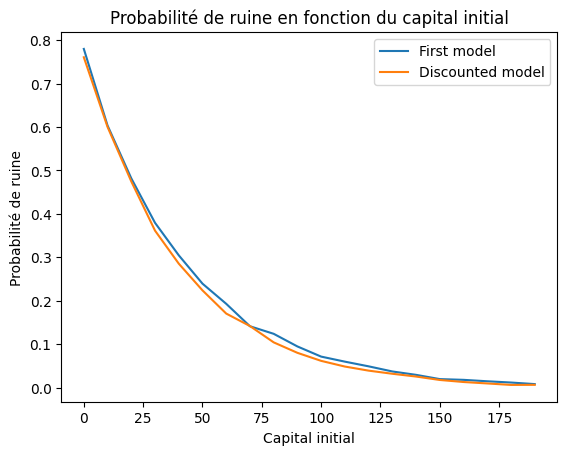

In [17]:
mu=1
T=100
beta=0.1
theta=0.3
n=10000
rho=0.001
proba_ruine=np.zeros(20)
proba_ruine_discounted=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine[k]=estimation_ruine(mu,T,beta,u[k],theta,n)
    proba_ruine_discounted[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho)

plt.plot(u,proba_ruine,label='First model')
plt.plot(u,proba_ruine_discounted,label='Discounted model')
plt.title("Probabilité de ruine en fonction du capital initial")
plt.xlabel("Capital initial")
plt.ylabel("Probabilité de ruine")
plt.legend()
plt.show()

As expected, for $\rho = 0.001$ the two curves are nearly indistinguishable , a numerical confirmation that the discounted model converges to the classical one as $\rho \to 0$. This validates our implementation and the theoretical result $p^*_{\text{discounted}} = p^*_{\text{classical}} = \mu m$.

### Sensitivity to the Discount Rate $\rho$

We now study how the ruin probability curve depends on the discount rate $\rho$. Intuitively, a higher $\rho$ means that past claims are discounted more aggressively , their effective burden on the reserve diminishes faster , which should translate into a lower ruin probability and a faster exponential decay with $u$. The following simulation tests four values of $\rho$ spanning two orders of magnitude.

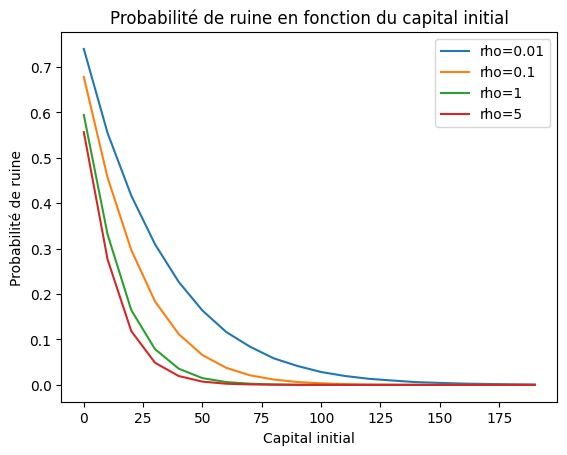

In [18]:
mu=1
T=100
beta=0.1
theta=0.3
n=100000
proba_ruine_1=np.zeros(20)
proba_ruine_2=np.zeros(20)
proba_ruine_3=np.zeros(20)
proba_ruine_4=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine_1[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=0.01)
    proba_ruine_2[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=0.1)
    proba_ruine_3[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=1)
    proba_ruine_4[k]=estimation_ruine_discounted(mu,T,beta,u[k],theta,n,rho=5)
    

plt.plot(u,proba_ruine_1,label='rho=0.01')
plt.plot(u,proba_ruine_2,label='rho=0.1')
plt.plot(u,proba_ruine_3,label='rho=1')
plt.plot(u,proba_ruine_4,label='rho=5')
plt.title("Probabilité de ruine en fonction du capital initial")
plt.xlabel("Capital initial")
plt.ylabel("Probabilité de ruine")
plt.legend()
plt.show()

### Interpretation and Conclusion

The simulation confirms the intuition: as $\rho$ increases, the ruin probability curve shifts **downward** and the exponential decay becomes **steeper** , the decay rate $\kappa_\rho$ is an increasing function of $\rho$. In the limit $\rho \to \infty$, all claims are instantaneously discounted to zero, the reserve grows deterministically at rate $p$, and ruin becomes impossible.

This behavior has a concrete risk-investment interpretation. In environments with a high discount rate , periods of high interest rates, or markets where liabilities are quickly liquidated , the discounted Cramér-Lundberg model is substantially more favourable for the insurer. Additional initial capital remains effective at reducing ruin risk (exponential decay in $u$ is preserved), but the insurer needs *less* capital to achieve the same safety level compared with the classical model, because past liabilities are worth less in the present.

Two structural conclusions emerge from this comparative study:

1. **The critical premium $p^* = \mu m$ is model-independent**: it is the same in both models, and in particular does not depend on $\rho$. The safety loading condition is a universal requirement rooted in the long-run balance between premiums and expected claims.

2. **Discounting concentrates risk in the short term**: while the classical model can drift to $-\infty$ if $p < p^*$, the discounted model always satisfies $\mathbb{E}[R_t] \to +\infty$ as $t \to \infty$. The insurer's vulnerability window narrows to a finite interval around the minimum $t^*$, after which the reserve recovers unconditionally.